# RiMEA 04: Measurement of the Fundamental Diagram

A long corridor (200 m x 10 m) with threee measuring points, one of which is the main measuring point with the other two functioning as control measuring points (RiMEA Guideline 4.1.1 Figure 5). The corridor is filled with different densities of persons with an equal as possible free walking speed of 1.2 m/s: 0.5 P/m^2 , 1 P/m^2 , 2 P/m^2 , 3 P/m^2. At measuring points, average speed of persons over 60 seconds (including 10 seconds of transient response) will be used to determine density. The corresponding fundamental diagrams are then created with **flow = speed * density**.

In [10]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 23 June 2026, 12:11 CEST


In [ ]:
from pathlib import Path
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon

from jupedsim_scenarios import load_scenario, run_scenario, run_sweep

In [12]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load the scenario

In [17]:
SCENARIO_ZIP = Path("scenario_files") / "Rimea-04-fundamental-diagram.zip"
base = load_scenario(str(SCENARIO_ZIP))
print(base.summary())

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/rimea/scenario_files/Rimea-04-fundamental-diagram.zip
  Model:         WarpDriverModel
  Seed:          420
  Max time:      300s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~1000
    jps-distributions_0: 1000 agents


##  Sweep with N-Agents

In [21]:
sweep = run_sweep(
    base,
    axes={"num_agents": [1000,2000,4000,6000]},
    apply={"num_agents": lambda s, n: s.set_agent_count(0, n)},
    seeds=[42],
    workers=2,
)

df = sweep.to_dataframe()

DEBUG: Distribution jps-distributions_0 RAW params from JSON: {'number': 2000, 'radius': 0.2, 'v0': 1.2, 'flow_start_time': 0, 'flow_end_time': 10, 'percentage': None, 'distribution_mode': 'by_number', 'use_flow_spawning': False, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'v0_distribution': 'constant'}
DEBUG: Distribution jps-distributions_0 processed params: {'number': 2000, 'radius': 0.2, 'v0': 1.2, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'radius_std': None, 'v0_distribution': 'constant', 'v0_std': None, 'distribution_mode': 'by_number', 'percentage': None}
DEBUG: Processing distribution with dist_key = 'jps-distributions_0'
DEBUG: Availa

In [38]:
# ---- Config ----
CORRIDOR_AREA = 200 * 10
FPS = 10.0
T_MIN, T_MAX = 10, 60

GATES = {
    "control1": {"x": 50, "x_tol": 1.0, "y_min": 6.0, "y_max": 8.0},
    "main":     {"x": 100, "x_tol": 1.0, "y_min": 6.0, "y_max": 8.0},
    "control2": {"x": 100, "x_tol": 1.0, "y_min": 4.0, "y_max": 6.0},
}


def compute_speeds(sqlite_path, fps=FPS, t_min=T_MIN, t_max=T_MAX, gates=GATES):
    conn = sqlite3.connect(sqlite_path)
    traj = pd.read_sql("SELECT frame, id, pos_x, pos_y FROM trajectory_data", conn)
    conn.close()

    traj = traj.sort_values(["id", "frame"])
    traj["time"] = traj["frame"] / fps
    traj["dx"] = traj.groupby("id")["pos_x"].diff()
    traj["dy"] = traj.groupby("id")["pos_y"].diff()
    traj["dt"] = traj.groupby("id")["time"].diff()
    traj["speed"] = np.sqrt(traj["dx"]**2 + traj["dy"]**2) / traj["dt"]

    traj = traj.dropna(subset=["speed"])
    traj = traj[traj["dt"] > 0]
    traj = traj[(traj["time"] >= t_min) & (traj["time"] <= t_max)]

    results = {}
    for gate_name, g in gates.items():
        near_gate = traj[
            (traj["pos_x"] >= g["x"] - g["x_tol"]) & (traj["pos_x"] <= g["x"] + g["x_tol"]) &
            (traj["pos_y"] >= g["y_min"]) & (traj["pos_y"] <= g["y_max"])
        ]
        results[gate_name] = near_gate["speed"].mean() if len(near_gate) > 0 else np.nan

    return results


def local_density_at_gate(sqlite_path, gate, fps=FPS, t_min=T_MIN, t_max=T_MAX):
    conn = sqlite3.connect(sqlite_path)
    traj = pd.read_sql("SELECT frame, id, pos_x, pos_y FROM trajectory_data", conn)
    conn.close()
    traj["time"] = traj["frame"] / fps
    window = traj[(traj["time"] >= t_min) & (traj["time"] <= t_max)]

    near_gate = window[
        (window["pos_x"] >= gate["x"] - gate["x_tol"]) & (window["pos_x"] <= gate["x"] + gate["x_tol"]) &
        (window["pos_y"] >= gate["y_min"]) & (window["pos_y"] <= gate["y_max"])
    ]

    gate_area = (2 * gate["x_tol"]) * (gate["y_max"] - gate["y_min"])
    counts_per_frame = near_gate.groupby("frame")["id"].nunique()
    if len(counts_per_frame) == 0:
        return np.nan
    return counts_per_frame.mean() / gate_area


# ---- Records with local density per gate ----
records = []
for _, row in df.iterrows():
    speeds = compute_speeds(row["sqlite_path"])
    for gate_name, speed in speeds.items():
        local_rho = local_density_at_gate(row["sqlite_path"], GATES[gate_name])
        records.append({
            "num_agents": row["num_agents"],
            "measuring_point": gate_name,
            "speed": speed,
            "density": local_rho,   # <- replaces nominal density
        })

speed_df = pd.DataFrame(records)
speed_df["flow"] = speed_df["speed"] * speed_df["density"]

summary = speed_df.sort_values(["measuring_point", "density"]).reset_index(drop=True)
print(summary)

    num_agents measuring_point     speed   density      flow
0         1000        control1  1.192607  0.660937  0.788239
1         2000        control1  1.185635  1.067109  1.265202
2         4000        control1  1.177630  1.809868  2.131356
3         6000        control1  1.166979  2.279805  2.660484
4         1000        control2  1.194988  0.657464  0.785662
5         2000        control2  1.191803  1.126747  1.342860
6         4000        control2  1.196861  2.014471  2.411041
7         6000        control2  1.193837  2.938623  3.508238
8         1000            main  1.192409  0.659639  0.786559
9         2000            main  1.191856  1.056387  1.259062
10        4000            main  1.196194  1.981537  2.370303
11        6000            main  1.194306  2.910679  3.476241


##  Plot Fundamental Diagrams

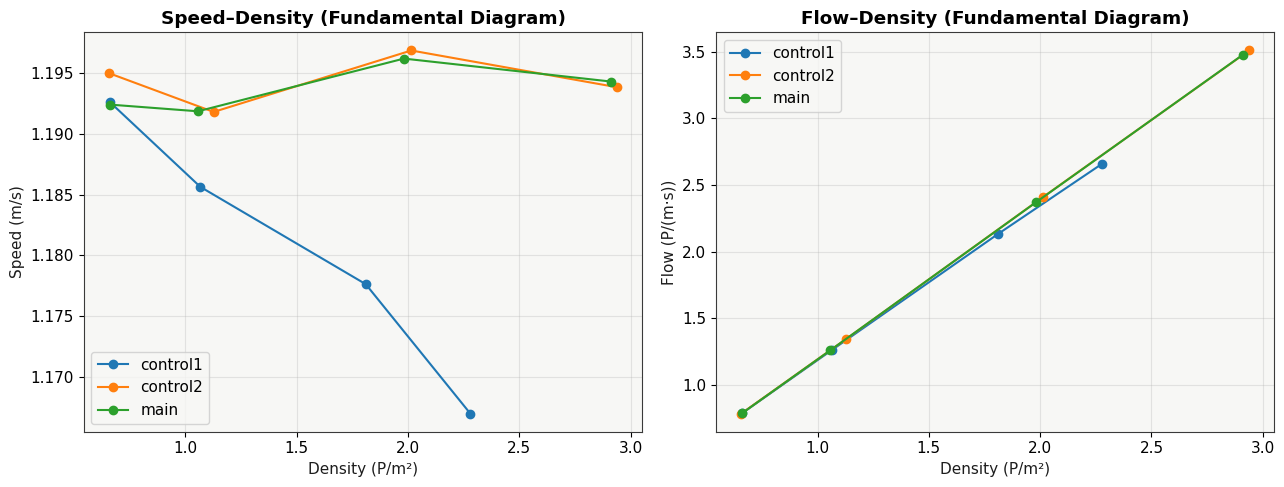

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for gate_name in summary["measuring_point"].unique():
    sub = summary[summary["measuring_point"] == gate_name]
    axes[0].plot(sub["density"], sub["speed"], marker="o", label=gate_name)
    axes[1].plot(sub["density"], sub["flow"], marker="o", label=gate_name)

axes[0].set_xlabel("Density (P/m²)")
axes[0].set_ylabel("Speed (m/s)")
axes[0].set_title("Speed–Density (Fundamental Diagram)")
axes[0].legend()

axes[1].set_xlabel("Density (P/m²)")
axes[1].set_ylabel("Flow (P/(m·s))")
axes[1].set_title("Flow–Density (Fundamental Diagram)")
axes[1].legend()

plt.tight_layout()
plt.show()

##  Acceptance

In [41]:
main_only = summary[summary["measuring_point"] == "main"]
print(main_only)
sweep.cleanup()

    num_agents measuring_point     speed   density      flow
8         1000            main  1.192409  0.659639  0.786559
9         2000            main  1.191856  1.056387  1.259062
10        4000            main  1.196194  1.981537  2.370303
11        6000            main  1.194306  2.910679  3.476241
